In [3]:
import os
import sys
os.chdir('/zhome/71/c/146676/main/')
sys.path.append('/zhome/71/c/146676/main/')
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import h5py
print(1)
from sklearn.model_selection import train_test_split
from interactive_notebooks.n21_attachment import ThresholdedH5Dataset
from torch.utils.data import DataLoader, Dataset
from scipy.interpolate import interp1d
from numpy.linalg import lstsq
from scipy.optimize import nnls  # non-negative least squares
from sklearn.linear_model import Lasso
from tqdm.auto import tqdm  # ✅ Recommended for notebooks
import math
import importlib


1


In [8]:
importlib.reload(sys.modules['interactive_notebooks.n21_attachment'])
from interactive_notebooks.n21_attachment import *

In [15]:
spectra = load_xy_files('/dtu-compute/msaca/sliceA_diffraction/cif-files_and_theoretical_pd_spectra/PowderDiff')
stds = np.linspace(0.1,10,10)
spectra = add_convolved_columns(spectra, stds)

In [37]:
threshold = 3.5
background_filter_sigma = 100
box = [30,70, 50, 200]
smoothness_index = 9
alpha = 0.1
theta_reg = False
j_global, k_global = 40, 100
slice_index = 46

In [38]:
key_to_name = simplified_keys()
keys = list(key_to_name.keys())
data_dir = '/dtu-compute/msaca/sliceA_diffraction/powder-crystal'
index_list, all_files = get_index_list(data_dir, theta_reg = theta_reg, slice_index=45)
dataset = ThresholdedH5Dataset(index_list, threshold=threshold)
num_background = 5
A, keys = resample_basis_dict(spectra, smoothness_index, np.linspace(0, 18.4, 667))
#A = add_fourier_background_basis(A, np.linspace(0, 18.4, 667), num_frequencies=num_background)
materials = fit_all_pixels(dataset, A, alpha=alpha, box=box, background_filter_sigma=background_filter_sigma)

Processing /dtu-compute/msaca/sliceA_diffraction/powder-crystal/recons2-DA-0429.h5 with shape (667, 100, 362)
Total samples: 36200


  0%|          | 0/6000 [00:00<?, ?it/s]

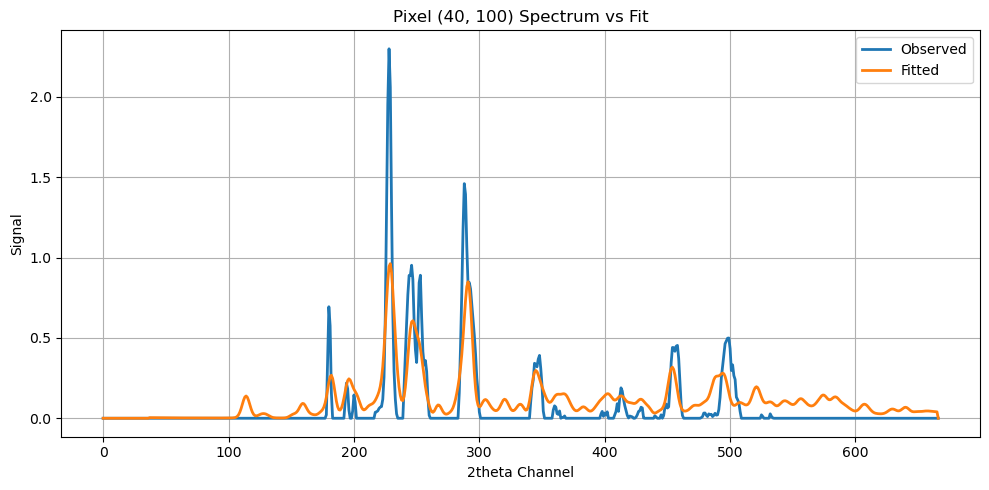

Key                       | Name                      | Scaled Value
-----------------------------------------------------------------
Na(AlSi3O8)_alb           | Albite                    | 0.7571
Fe2Si2O6_fer2             | Ferrosilite               | 0.2115
Mg2Si2O6_enst             | Enstatite                 | 0.0315


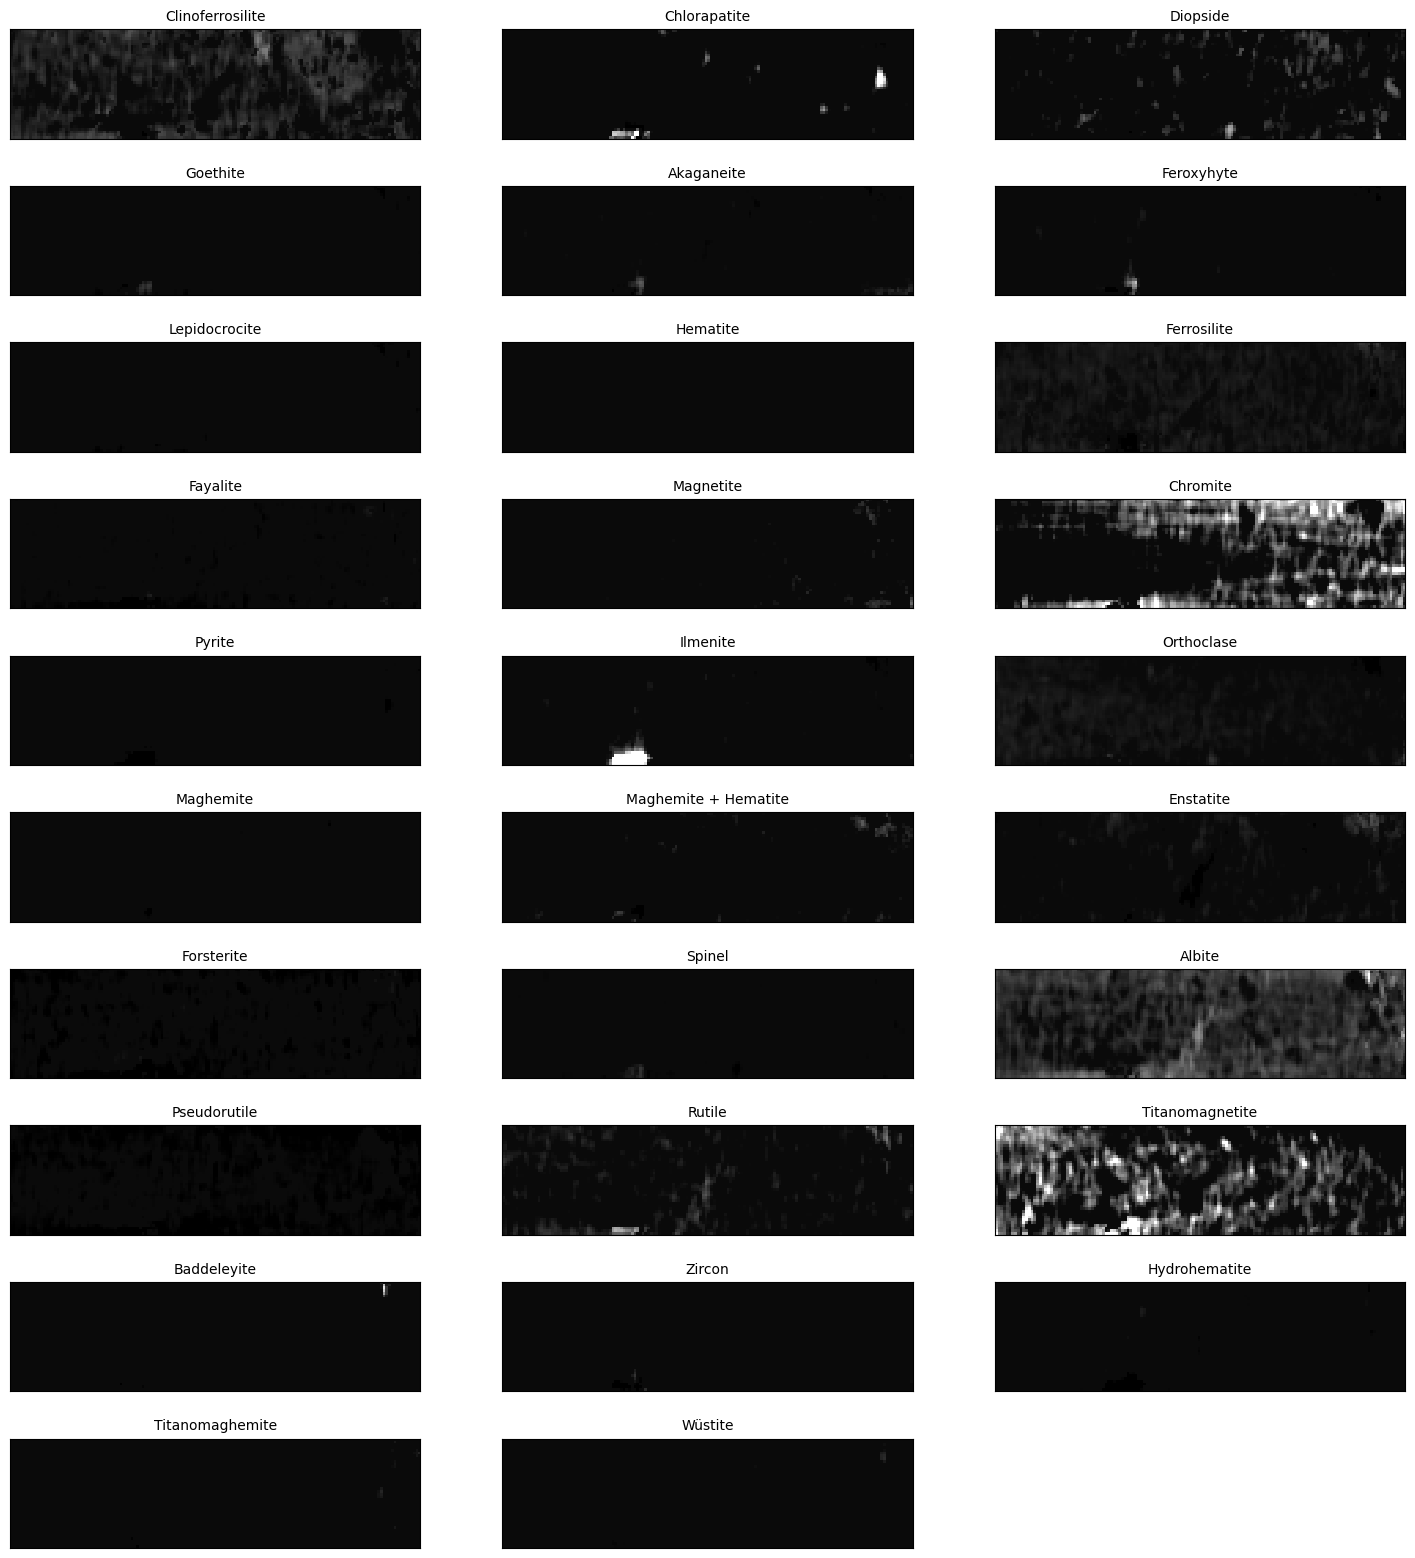

In [39]:
plot_pixel_fit(j_global=j_global, k_global=k_global, dataset=dataset, materials=materials,
               A=A, box=box,filename=all_files[0], background_filter_sigma=background_filter_sigma)

plot_material_maps_only(materials, keys, key_to_name, num_cols=3)
#plt.savefig('/dtu-compute/msaca/sliceA_diffraction/figures/example_decomp.png',dpi=500, bbox_inches='tight')

print_nonzero_material_coeffs(materials[:,25,100], keys, key_to_name, num_background=6, threshold=1e-8)


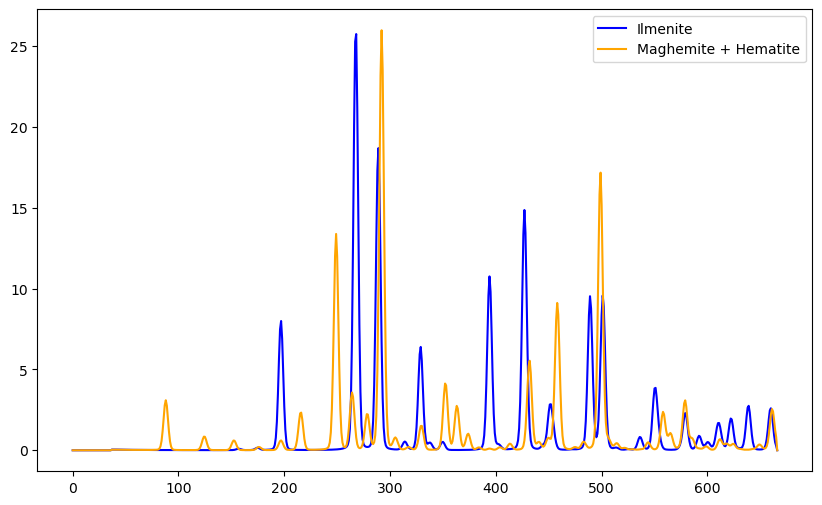

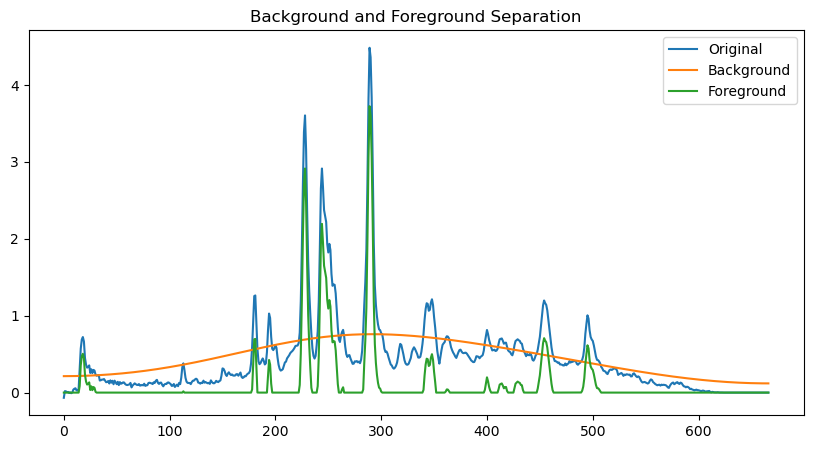

In [27]:
plt.figure(figsize=(10, 6))
keys = list(key_to_name.keys())
plt.plot(A[:, 13], label=key_to_name[keys[13]], color='blue')
plt.plot(A[:, 16], label=key_to_name[keys[16]], color='orange')
plt.legend()
plt.show()

idx = 200+100*100
y = dataset[idx]  # shape (667,)
if background_filter_sigma is not None:
    background = gaussian_filter1d(y, sigma=background_filter_sigma)
    foreground = y - background
    foreground[foreground < 0] = 0
    plt.figure(figsize=(10, 5))
    plt.plot(y)
    plt.plot(background)
    plt.plot(foreground)
    plt.title('Background and Foreground Separation')
    plt.legend(['Original', 'Background', 'Foreground'])
    plt.show()


In [139]:
import torch
from geomloss import SamplesLoss
y = dataset[100+362*50]
lambda_l1 = 0.0005
A, keys = resample_basis_dict(spectra, 4, np.linspace(0, 18.4, 667))
A = add_background_basis(A, np.linspace(0, 18.4, 667), degree=2)
A_ = torch.tensor(A[100:], dtype=torch.float32)
from scipy.ndimage import gaussian_filter1d


background = als_baseline(y)
foreground = y - background
foreground[foreground < 0] = 0
y_ = torch.tensor(foreground[100:], dtype=torch.float32)
y_ = y_ / y_.sum()  # Normalize
y_ = y_.view(-1, 1)

# Initialize c (40,), requires grad
c = torch.nn.Parameter(torch.ones(A_.shape[1], dtype=torch.float32), requires_grad=True)

# Sinkhorn loss (Wasserstein-1 with blur)
loss1_fn = SamplesLoss("sinkhorn", p=1, blur=0.000005)  # adjust blur for strength
loss2_fn = SamplesLoss("sinkhorn", p=2, blur=0.000005) 

optimizer = torch.optim.Adam([c], lr=0.5)

positions = torch.arange(567, dtype=torch.float32).reshape(-1, 1)
for step in range(100):
    optimizer.zero_grad()

    pred = torch.matmul(A_, torch.clamp(c, min=0))
    pred = pred / pred.sum()  # normalize prediction
    pred = pred.view(-1, 1)
    sinkhorn1_loss = loss1_fn(positions, pred, positions, y_)
    sinkhorn2_loss = loss2_fn(positions, pred, positions, y_)
    l1_penalty = torch.sum(torch.clamp(c, min=0))
    loss = sinkhorn1_loss + sinkhorn2_loss + lambda_l1 * l1_penalty
    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"Step {step}, Loss = {loss.item():.4f}")
pred = pred.detach().cpu().numpy()


Step 0, Loss = 216.6871
Step 20, Loss = 36.1440
Step 40, Loss = 34.5459
Step 60, Loss = 34.3092
Step 80, Loss = 34.2663


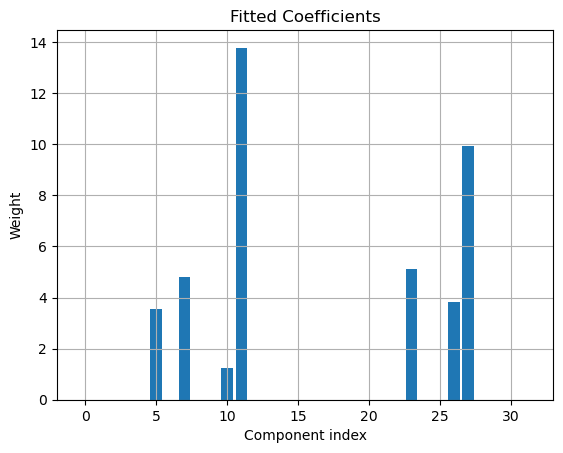

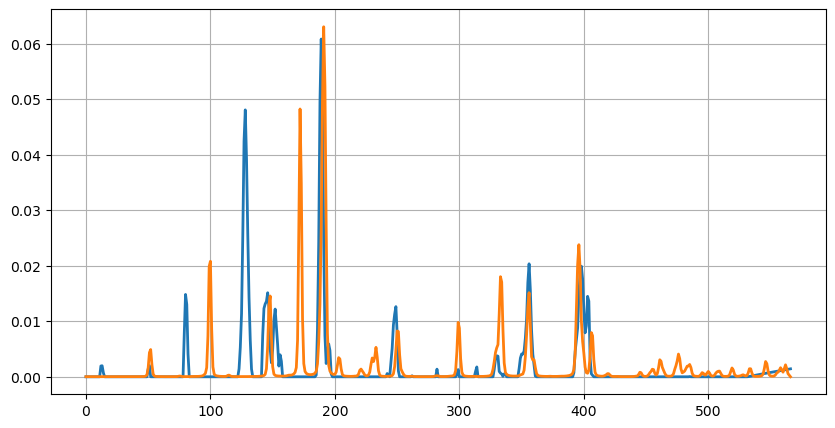

In [203]:
coeffs = torch.clamp(c, min=0).detach().cpu().numpy()
plt.bar(range(len(coeffs)), coeffs)
plt.title("Fitted Coefficients")
plt.xlabel("Component index")
plt.ylabel("Weight")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))
plt.plot(y_.numpy(), label='Observed', linewidth=2)
plt.plot(pred, label='Observed', linewidth=2)
plt.grid(True)
plt.show()
